summary

In [1]:
import numpy as np  
from collections import defaultdict, Counter
import xarray as xr  
import matplotlib.pyplot as plt  
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches  
import cartopy.crs as ccrs  
import geopandas as gpd  
from shapely.geometry import Point  

# Read in GRDC data and create a modified GRDC file that matched with calibration_multi_station_netcdf.py

#### GRDC Filename

In [3]:
GRDCFilename = 'GRDC_40calibrationStations_FINAL'

#### Load GRDC netcdf file

In [4]:
# Read GRDC-data-file
xr_grdc = xr.open_dataset('GRDC_data/GRDC_calibrationStations/' + GRDCFilename  + '.nc')

# Path and name of OUTPUT-GRDC-file 
xr_grdc_out = 'GRDC_data/GRDC_calibrationStations/' + GRDCFilename  + '_LatLonFit.nc'

# A netcdf-File with the same grid as the C-CWatM output grid is needed
xr_grid = xr.open_dataset('CWatM_exampleGrid/discharge_daily.nc')

# Read hydrological basins from  HydroBasins
gdf_hybas = gpd.read_file('HydroBasins_data/hybas_eu_lev05_v1c.shp') 
# nc-file über HybasBasins einlesen (vorangegangen Umwandlung von .shp-file in .nc-file)
xr_hybas = xr.open_dataset('HydroBasins_data/hybas_eu_lev05_v1c.nc')

# Number of HybasIDs in basin
xr_hybas_values = xr_hybas.sub_basin_mask.values
HybasID_list_unique_with0 = np.unique(xr_hybas_values)
HybasID_list_unique = np.setdiff1d(HybasID_list_unique_with0, [0, 1])
print(f'Anzahl der verschiedenen Hybas-IDs im Einzugsgebiet:', len(HybasID_list_unique))

# Read list of station IDs 
list_of_station_IDs = xr_grdc['id'].values

# Choose, which stations should be used for calibration and for validation 
calibration_IDs = list_of_station_IDs 
validation_IDs = []

# Read GRDC station coordinates
lon_station = {}
lat_station = {}
for ID in list_of_station_IDs: 
    lon_station [ID] = xr_grdc['geo_x'].sel(id = ID).values
    lat_station [ID] = xr_grdc['geo_y'].sel(id = ID).values

# Read simulation coordinates
latitudes = xr_grid['lat'].values
longitudes = xr_grid['lon'].values

# Find closest grid indeces for GRDC stations
lat_station_index = {}
lon_station_index = {}
for i in range(len(list_of_station_IDs)): 
    ID = list_of_station_IDs[i]
    lat_station_index [ID] = np.abs(latitudes - lat_station[ID]).argmin()
    lon_station_index [ID] = np.abs(longitudes - lon_station[ID]).argmin()

Anzahl der verschiedenen Hybas-IDs im Einzugsgebiet: 346


#### Modifying the GRDC file to match with calibration_multi_station_netcdf.py
- Add the longitudes and latitudes, that represent the best position of the stations within the simulation grid (these positions can sightly vary from the automatically calculated positions within the grid!) 
- Add a boolean variable (here named 'calibrated') that specifies if GRDC station is used for calibration or for validation: 1 for calibration, 0 for validation. 
- Add the HydroBasin-IDs from HydroBaisns-Website

In [5]:
# From Step0A_FindBestRaster_calibration.ipynb
# Choose which stations need to be adjusted manually 
list_of_station_IDs_lat_minus1 = [ 6212450 , 6226300 , 6227410 , 6226310 , 6227130 , 6217400 , 
                                   6605615 , 6139770 , 6221102 , 6348610 , 6935302 , 6233650 , 
                                   6233690 , 6854702 , 6854101 , 6172351 , 6573800 , 6335020 , 
                                   6337100 , 6337400 , 6546610 , 6781800 , 6457200 , 6444200 , 
                                   6444430 , 6213750 , 6123510 , 6124045 , 6935300 ] 
list_of_station_IDs_lon_minus1 = [ 6212740 , 6211520 , 6139284 , 6574300 , 6342500, 6342501 , 
                                   6144200 , 6227510 , 6123300 ]
list_of_station_IDs_lat_plus1  = [ 6340501 , 6227510 ]
list_of_station_IDs_lon_plus1  = [ 6216610 , 6172351 , 6340180 , 6546610 , 6373304 , 6744201,
                                   6118800 , 6742600 ]

In [6]:
lat_station_index_fit = {}
lon_station_index_fit = {}
for ID in list_of_station_IDs:
    lat_station_index_fit[ID] = lat_station_index[ID]
    lon_station_index_fit[ID] = lon_station_index[ID]

for ID in set(list_of_station_IDs_lat_minus1) & set(list_of_station_IDs):
    lat_station_index_fit[ID] = lat_station_index[ID] - 1 
for ID in set(list_of_station_IDs_lon_minus1) & set(list_of_station_IDs):
    lon_station_index_fit[ID] = lon_station_index[ID] - 1
for ID in set(list_of_station_IDs_lat_plus1) & set(list_of_station_IDs):
    lat_station_index_fit[ID] = lat_station_index[ID] + 1 
for ID in set(list_of_station_IDs_lon_plus1) & set(list_of_station_IDs):
    lon_station_index_fit[ID] = lon_station_index[ID] + 1

lat_station_fit = {}
lon_station_fit = {}
for ID in list_of_station_IDs: 
    lat_station_fit[ID] = np.round(lat_station[ID] - 5/60*(lat_station_index_fit[ID]-lat_station_index[ID]) , 4)
    lon_station_fit[ID] = np.round(lon_station[ID] + 5/60*(lon_station_index_fit[ID]-lon_station_index[ID]) , 4)
lat_station_fit_list = [lat_station_fit [ID] for ID in list_of_station_IDs]  # Dictionary in Liste umwandeln
lon_station_fit_list = [lon_station_fit [ID] for ID in list_of_station_IDs]  # Dictionary in Liste umwandeln

#### Add additional values to the final GRDC-file

In [7]:
# Add boolean variable (here named 'calibrated') to differentiate between calibration and validation
# 1 for calibration, 0 for validation.  
boolean_calval = {} 
for ID in calibration_IDs:
    boolean_calval[ID] = 1
for ID in validation_IDs: 
    boolean_calval[ID] = 0
boolean_calval_list = [boolean_calval [ID] for ID in list_of_station_IDs]  # Dictionary in Liste umwandeln

# Read HYBAS-ID (hydrological basins) using HydroBasins shapefile
HybasID = {}
for ID in list_of_station_IDs: 
    point_to_check = Point(lon_station_fit[ID], lat_station_fit[ID])  # Einen Punkt (Longitude, Latitude) für jede Station erstellen
    point_in_region = gdf_hybas.contains(point_to_check)  # Prüfen, in welchem Polygon der Punkt liegt
    region_index = point_in_region.idxmax() if point_in_region.any() else None      # Falls der Punkt in einem Polygon enthalten ist, den Index des ersten Treffers extrahieren
    HybasID[ID] = gdf_hybas.iloc[region_index]['HYBAS_ID'] # Die entsprechende HYBAS-ID aus dem GeoDataFrame holen und zur Liste hinzufügen
HybasID_list =  [HybasID [ID] for ID in list_of_station_IDs]  # Dictionary in Liste umwandeln

# New netcdf-variables 
newlat_dict = {
    'data' : lat_station_fit_list,
    'dims' : ['id'], 
    'coords' : {'id': {'dims': 'id', 'data': list_of_station_IDs}} }
newlon_dict = {
    'data' : lon_station_fit_list, 
    'dims' : ['id'],  
    'coords' : {'id': {'dims': 'id', 'data': list_of_station_IDs}} }
HybasID_dict = {
    'data' : HybasID_list,
    'dims' : ['id'],  
    'coords' : {'id': {'dims': 'id', 'data': list_of_station_IDs}}  }
calval_dict = {
    'data' : boolean_calval_list,
    'dims' : ['id'], 
    'coords' : {'id': {'dims': 'id', 'data': list_of_station_IDs}} }

# Information on dictionary structure
newlat_array = xr.DataArray.from_dict(newlat_dict)
newlon_array = xr.DataArray.from_dict(newlon_dict)
calval_array = xr.DataArray.from_dict(calval_dict)
HybasID_array = xr.DataArray.from_dict(HybasID_dict)

# Array names 
# DO NOT CHANGE 
newlat_array.name =  'gauged_lat'
newlon_array.name =  'gauged_lon'
calval_array.name =  'calibrated'
HybasID_array.name = 'OBJECTID'

# Add data to original array 
xr_grdc_mod = xr.merge([xr_grdc, newlat_array, newlon_array, calval_array, HybasID_array])

# Save array with modified data
xr_grdc_mod.to_netcdf(xr_grdc_out)

# Find whether some GRDC-Stationen belong to the same HydroBasin
Check here, to avoid problems with regionalization

#### Test original choice

In [8]:
# Dictionary with station IDs and corresponding HybasIDs 
HybasID_list =  [HybasID [ID] for ID in list_of_station_IDs] 
HybasID_ID_dict = {hybasID: ID for hybasID, ID in zip(HybasID_list, list_of_station_IDs)}

# Vice versa
HybasID_ID_dict = defaultdict(list)
for hybasID, stationID in zip(HybasID_list, list_of_station_IDs):
    HybasID_ID_dict[hybasID].append(stationID)

# Filter dictionary to keep only HybasIDs with more that 1 occurrrence
hybasID_count = Counter(HybasID_list)
multiple_HybasIDs = {hybasID: stationID for hybasID, stationID in HybasID_ID_dict.items() if hybasID_count[hybasID] > 1}

if multiple_HybasIDs:
    print(f'Stations that belong to the same HybasID:')
    for hybasID, IDs in multiple_HybasIDs.items():
        print(f"Stationen: {IDs}, HybasID: {hybasID}")
else:
    print(f"No stations belong to the same HydroBasin!")


Keine Stationen gehören zur gleichen HydroBasin!


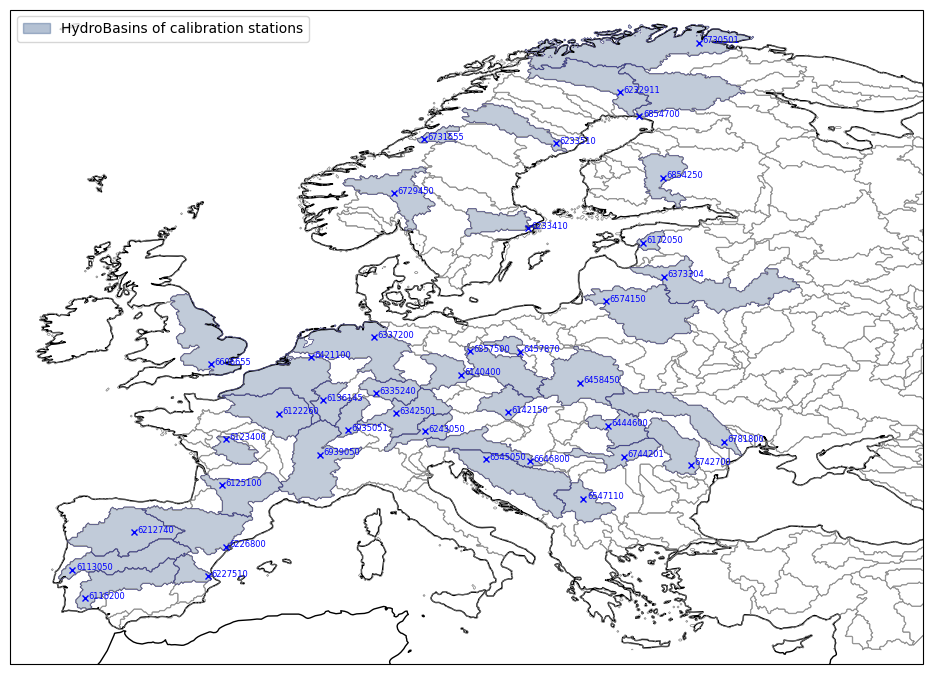

In [9]:
# Create a map figure with matplotlib and cartopy
A_lon, A_lat, B_lon, B_lat = -12 , 34 , 41 , 72
choosen_projection = ccrs.PlateCarree()  
fig,ax = plt.subplots(figsize=(20, 8.5),subplot_kw={'projection': choosen_projection})
ax.set_extent([A_lon, B_lon, A_lat, B_lat], crs = choosen_projection)
ax.coastlines(linewidth=1, linestyle='-')

# Color map for the areas
cmapBlue = plt.cm.Blues
cmapGreen = plt.cm.Greens
cmapRed = plt.cm.Reds
norm = mcolors.Normalize(vmin=0, vmax=1)  # Define the range for the color map

# Borders of all HybasBasins
for i in range (0, len(HybasID_list_unique)) :
    # HydroBasins data: Zugehörige HydroBasins, die im modifizierten GRDC-File vorab gespeichert wurden 
    Hybas_ID = HybasID_list_unique [i]  
    # Randlinie hinzufügen
    mask = xr.where(xr_hybas.sub_basin_mask == Hybas_ID, 1, 0)
    lon2d, lat2d = np.meshgrid(mask.lon, mask.lat, indexing='ij')
    ax.contour(lon2d, lat2d, mask, levels=[0.3], colors='gray', linewidths=0.5, transform=choosen_projection)

# Calibration stations
for ID in list_of_station_IDs:
# for ID in optimized_list_of_station_IDs:  
    # GRDC data Calibration: Lat Fit & Lon Fit, die im modifizierten GRDC-File vorab gespeichert wurden 
    ax.plot(xr_grdc_mod.gauged_lon.sel(id=ID), xr_grdc_mod.gauged_lat.sel(id=ID),  'x' , color='b' , markersize=5, transform = choosen_projection)
    ax.text(xr_grdc_mod.gauged_lon.sel(id=ID) + 0.2 , xr_grdc_mod.gauged_lat.sel(id=ID) , str(ID),  color='b' , fontsize= 6 , transform = choosen_projection)
    
    # HydroBasins data: Corresponding HydroBasins, from modified GRDC file 
    Hybas_ID = float(xr_grdc_mod.sel(id=ID).OBJECTID.values)   
    # isolate sub-basin with corresponding Hybas_IDs
    filtered_xr_hybas = xr_hybas.where(xr_hybas.sub_basin_mask == Hybas_ID, drop=True)
    map_filtered_hybas = filtered_xr_hybas.sub_basin_mask
    # Plot catchment area for each Hybas_ID [ID] 
    map_filtered_hybas.plot(x='lon', y='lat', ax=ax, add_colorbar=False, alpha=0.25, cmap=cmapBlue, norm=norm)
    mask = xr.where(xr_hybas.sub_basin_mask == Hybas_ID, 1, 0)
    lon2d, lat2d = np.meshgrid(mask.lon, mask.lat, indexing='ij')
    ax.contour(lon2d, lat2d, mask, levels=[0.3], colors='darkblue', linewidths=0.2, transform=choosen_projection)
    
# Legend
blue_patch = mpatches.Patch(color=cmapBlue (0.99), alpha=0.3, label='HydroBasins of calibration stations')
ax.legend(handles=[blue_patch], loc='upper left')  
plt.show()
plt.close()

# Check "Number of missing days"

In [10]:
def calculate_NaN(stationID, Dict_obs_data):
    obs_data = Dict_obs_data[stationID]
    NrOfNan = np.sum(np.isnan(obs_data))
    return stationID, NrOfNan

### 1st time period ###
# Start and end times
start_date = '1989-01-01'
end_date = '1998-12-31'

# Select data between start and end dates
Dict_obs_data = {}
for ID in list_of_station_IDs:
    obs_data = xr_grdc['runoff_mean'].sel(id = ID, time = slice (start_date, end_date)).values
    Dict_obs_data[ID] = obs_data

# NaN for 1st period
NrOfNan1 = {}
for ID in list_of_station_IDs:
    stationID,  stationNrOfNan = calculate_NaN(ID, Dict_obs_data) 
    NrOfNan1 [ID] = stationNrOfNan

### 2nd time period ###
# Start and end times
start_date = '1999-01-01'
end_date = '2008-12-31'

# SSelect data between start and end dates
Dict_obs_data = {}
for ID in list_of_station_IDs:
    obs_data = xr_grdc['runoff_mean'].sel(id = ID, time = slice (start_date, end_date)).values
    Dict_obs_data[ID] = obs_data

# NaN for 2nd period
NrOfNan2 = {}
for ID in list_of_station_IDs:
    stationID,  stationNrOfNan = calculate_NaN(ID, Dict_obs_data) 
    NrOfNan2 [ID] = stationNrOfNan

# Print station info

In [12]:
# sorted_list_of_station_IDs calibration
sorted_list_of_station_IDs = [ 
    6113050, 6116200, 6226800, 6212740, 6227510, 6606655,
    6421100, 6123400, 6125100, 6136145, 6122260, 6340160,
    6342900, 6357500, 6337200, 6335240, 6342501, 6935051, 
    6939050, 6730501, 6729450, 6731555, 6233410, 6233510,
    6232911, 6854700, 6854250, 6172050, 6373304, 6574150, 
    6458450, 6457870, 6140400, 6142150, 6243050, 6444600, 
    6545050, 6646800, 6547110, 6742700, 6744201, 6781800   ]

for ID in sorted_list_of_station_IDs:
    print(NrOfNan1 [ID])
print('---------------------------------')

for ID in sorted_list_of_station_IDs:
    print(NrOfNan2 [ID])
print('---------------------------------')

for ID in sorted_list_of_station_IDs:
    print(HybasID [ID])
print('---------------------------------')

### ---------------------------------------- THE END ------------------------------------------- 
